In [2]:
import pandas as pd
import requests

In [2]:
# Obter dados de câmbio por meio do BCB
# Séries SGS 10813 - Dólar Comercial (venda)
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados"
params = {
    "formato": "json",
    "dataInicial": "01/01/2023",
    "dataFinal":   "31/12/2024"
}

response = requests.get(url, params=params)
df_cambio = pd.DataFrame(response.json())

pd.concat([df_cambio.head(5), df_cambio.tail(5)])

,data,valor
0,02/01/2023,5.3430
1,03/01/2023,5.3753
2,04/01/2023,5.4453
3,05/01/2023,5.4020
4,06/01/2023,5.2849
497,24/12/2024,6.1527
498,26/12/2024,6.1650
499,27/12/2024,6.1985
500,30/12/2024,6.1917
501,31/12/2024,6.1917


In [3]:
# Tratamento inicial e conversão para FLOAT (corrigindo a vírgula)
df_cambio["data"] = pd.to_datetime(df_cambio["data"], dayfirst=True)
df_cambio["usd_brl"] = df_cambio["valor"].str.replace(',', '.').astype(float)

# Criar o calendário completo e preencher os buracos (sáb/dom/feriados)
df_cambio = df_cambio.set_index("data")
calendario_completo = pd.date_range("2023-01-01", "2024-12-31", freq="D")
df_cambio = df_cambio.reindex(calendario_completo)

# Aplicar o forward fill (pegar o valor do último dia útil disponível)
df_cambio["usd_brl"] = df_cambio["usd_brl"].ffill().bfill()

# LIMPEZA FINAL: Remove a coluna 'valor' original e renomeia o índice
# Transforma o índice de volta em coluna e já damos o nome 'data_cambio'
df_cambio = df_cambio.reset_index().rename(columns={"index": "data_cambio"})

# Remove qualquer resquício da coluna 'valor' se ela ainda existir
if 'valor' in df_cambio.columns:
    df_cambio = df_cambio.drop(columns=['valor'])

print(f"Câmbio: {len(df_cambio)} dias | nulos: {df_cambio['usd_brl'].isna().sum()}")

pd.concat([df_cambio.head(5), df_cambio.tail(5)])

Câmbio: 731 dias | nulos: 0


,data_cambio,usd_brl
0,2023-01-01,5.3430
1,2023-01-02,5.3430
2,2023-01-03,5.3753
3,2023-01-04,5.4453
4,2023-01-05,5.4020
726,2024-12-27,6.1985
727,2024-12-28,6.1985
728,2024-12-29,6.1985
729,2024-12-30,6.1917
730,2024-12-31,6.1917


In [4]:
df_cambio.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   data_cambio  731 non-null    datetime64[us]
 1   usd_brl      731 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.6 KB


In [5]:
# Exportar para CSV
df_cambio.to_csv('../datasets_aux/historico_cambio_bcb.csv', index=False)
print("Ficheiro 'historico_cambio_bcb' guardado com sucesso!")

Ficheiro 'historico_cambio_bcb' guardado com sucesso!


In [3]:
# Carregar Vendas e Custos
vendas = pd.read_csv('../datasets_tratados/vendas_normalizadas.csv')
custos = pd.read_csv('../datasets_tratados/custos_importacao.csv')
df_cambio = pd.read_csv('../datasets_aux/historico_cambio_bcb.csv')

In [4]:
print(f"Nulos vendas: {vendas['sale_date'].isnull().sum()}")
print(f"Nulos custos: {custos['start_date'].isnull().sum()}")

Nulos vendas: 0
Nulos custos: 0


In [5]:
# Preparação dos tipos de dados
# Garantir que o df_cambio use o 'data_cambio' e seja datetime
df_cambio['data_cambio'] = pd.to_datetime(df_cambio['data_cambio'])

# Garantir que vendas e custos também seja datetime
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'])
custos['start_date'] = pd.to_datetime(custos['start_date'])

> Parte 1 - Cálculo e Modelagem

In [20]:
# Merge de Câmbio + Vendas
# Unindo vendas com o câmbio do dia
vendas_cambio = pd.merge(
    vendas,
    df_cambio[['data_cambio', 'usd_brl']],
    left_on='sale_date',
    right_on='data_cambio',
    how='left'
)

vendas_cambio.head()

,id,id_client,id_product,qtd,total,sale_date,data_cambio,usd_brl
0,0,42,105,11,3405.0,2023-09-10,2023-09-10,4.9829
1,1,3,136,9,16873.9,2024-09-15,2024-09-15,5.5711
2,2,25,139,7,9475.3,2024-08-13,2024-08-13,5.4869
3,4,20,23,5,55893.0,2023-02-03,2023-02-03,5.1024
4,5,8,57,4,451403.9,2024-02-12,2024-02-12,4.9711


In [ ]:
# Merge de Custos - Vendas/CÂmbio + Custos
# Ordenação obrigatória para merge_asof
vendas_cambio = vendas_cambio.sort_values('sale_date')
custos = custos.sort_values('start_date')

# Cruzamento final
df_final = pd.merge_asof(
    vendas_cambio,
    custos[['product_id', 'start_date', 'usd_price', 'product_name']],
    left_on='sale_date',
    right_on='start_date',
    left_by='id_product',
    right_by='product_id',
    direction='backward'
)

print(f"Vendas cruzadas com cÂmbio e custos: {df_final.shape[0]} linhas")
print(df_final.head())

Vendas cruzadas com cÂmbio e custos: 9895 linhas
     id  id_client  id_product  qtd      total  sale_date data_cambio  \
0  1230         17          91    4  512566.80 2023-01-01  2023-01-01   
1  4997         23         133    1    1893.00 2023-01-01  2023-01-01   
2  3131         28         130   13   53873.00 2023-01-01  2023-01-01   
3  4212          9          96    6  402538.75 2023-01-01  2023-01-01   
4  4294          7          44    5   51332.30 2023-01-01  2023-01-01   

   usd_brl  product_id start_date  usd_price  \
0    5.343          91 2022-03-16   26303.31   
1    5.343         133 2022-07-06     348.47   
2    5.343         130 2021-03-22     749.89   
3    5.343          96 2022-09-30   13063.42   
4    5.343          44 2022-01-17    1963.02   

                                  product_name  
0  Motor Elétrico Tohatsu Zenith Oceanic 113HP  
1                      Âncora Bruce Core Pulse  
2   Boia de Arqueamento Delta Zen Boost Vortex  
3      Motor de Popa Tohats

> Parte 1 - Cálculo e Modelagem

In [81]:
import numpy as np

# Define como vai ser exibido os números float de forma global
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Passo 1: custo unitário em BRL
# O usd_price do catálogo é UNITÁRIO, então custo_brl também é unitário
df_final["custo_brl"] = df_final["usd_price"] * df_final["usd_brl"]

# Passo 2: custo TOTAL da transação (unitário × quantidade) 
df_final["custo_total_brl"] = df_final["custo_brl"] * df_final["qtd"]

# Passo 3: flag e valor de prejuízo por transação 
df_final["prejuizo"] = df_final["custo_total_brl"] > df_final["total"]

df_final["valor_prejuizo"] = np.where(
    df_final["prejuizo"],
    df_final["custo_total_brl"] - df_final["total"],
    0.0
)

# Conferência
transacoes_com_prejuizo = df_final[df_final["prejuizo"]]
print('-'*90)
print(f"Transações com prejuízo: {len(transacoes_com_prejuizo)}")
print('-'*90)
print(transacoes_com_prejuizo[
    ["id", "sale_date", "product_name", "total", "custo_total_brl", "valor_prejuizo"]
].head())
print('-'*90)

------------------------------------------------------------------------------------------
Transações com prejuízo: 6169
------------------------------------------------------------------------------------------
     id  sale_date                                   product_name      total  \
0  1230 2023-01-01    Motor Elétrico Tohatsu Zenith Oceanic 113HP 512,566.80   
3  4212 2023-01-01        Motor de Popa Tohatsu Boost Swift 126HP 402,538.75   
4  4294 2023-01-01                      GPS Simrad Zen Hydra Peak  51,332.30   
5  2300 2023-01-01             Motor Diesel Honda Leviathan 133HP 596,858.40   
6  3549 2023-01-01  Motor Elétrico Torqeedo Zen Titan Hydra 129HP 662,886.25   

   custo_total_brl  valor_prejuizo  
0       562,154.34       49,587.54  
3       418,787.12       16,248.37  
4        52,442.08        1,109.78  
5       622,516.51       25,658.11  
6       691,716.48       28,830.23  
-------------------------------------------------------------------------------------

In [80]:
# Passo 4: agregar por id_product 
resultado = df_final.groupby(["id_product", "product_name"]).agg(
    receita_total   = ("total",          "sum"),
    custo_total_brl = ("custo_total_brl","sum"),
    prejuizo_total  = ("valor_prejuizo", "sum"),
    n_vendas        = ("id",             "count"),
    n_transacoes_prejuizo = ("prejuizo", "sum")
).reset_index()

# Percentual de perda = prejuízo total / receita total
resultado["pct_perda"] = (
    resultado["prejuizo_total"] / resultado["receita_total"] * 100
).round(2)

resultado = resultado.sort_values("prejuizo_total", ascending=False)

print('-'*90)
print("Top 10 produtos com maior prejuízo:")
print('-'*90)
print(resultado[resultado["prejuizo_total"] > 0][
    ["product_name", "receita_total", "prejuizo_total", "pct_perda"]
].head(10).to_string())
print('-'*90)

------------------------------------------------------------------------------------------
Top 10 produtos com maior prejuízo:
------------------------------------------------------------------------------------------
                                    product_name  receita_total  prejuizo_total  pct_perda
71          Motor de Popa Volvo Hydro Dash 256HP  63,057,815.65   39,809,090.51      63.13
82          Motor Diesel Yanmar Dash Nitro 184HP  44,377,440.00   18,607,005.07      41.93
73              Motor de Popa Honda Torque 228HP  59,764,356.15    6,710,786.10      11.23
70           Motor Elétrico Torqeedo Pulse 300HP  81,567,066.65    6,062,177.38       7.43
54         Motor Diesel Volvo Flow Oceanic 259HP  61,224,375.00    5,363,535.68       8.76
90   Motor Elétrico Tohatsu Zenith Oceanic 113HP  66,829,268.70    4,889,956.54       7.32
62    Motor Elétrico Torqeedo Ion Orca Vox 186HP  68,817,185.90    4,841,834.79       7.04
77          Motor Elétrico Honda Mako Axis 131HP  58,0

> Parte 2 - Análise Visual

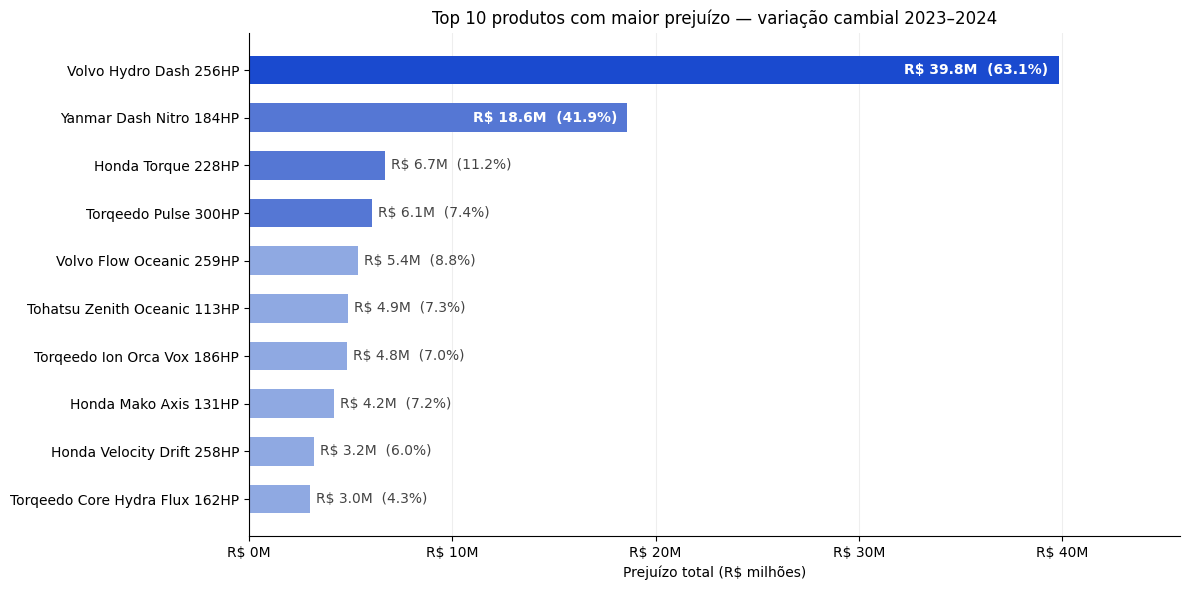

In [83]:
import matplotlib.pyplot as plt

top10 = (
    resultado[resultado["prejuizo_total"] > 0]
    .nlargest(10, "prejuizo_total")
    .sort_values("prejuizo_total", ascending=True)
)

nomes   = top10["product_name"].str.replace(r"Motor (de Popa |Diesel |Elétrico )", "", regex=True)
valores = top10["prejuizo_total"] / 1e6
pcts    = top10["pct_perda"]
cores   = ["#1A4ACF" if v == max(valores) else "#5577D4" if v >= 6 else "#8FA9E2"
           for v in valores]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(nomes, valores, color=cores, height=0.6)

limiar = valores.max() * 0.35  # barras acima disso recebem rótulo interno

for bar, v, p in zip(bars, valores, pcts):
    label = f"R$ {v:.1f}M  ({p:.1f}%)"
    if v >= limiar:
        ax.text(v - 0.5, bar.get_y() + bar.get_height() / 2,
                label, va="center", ha="right",
                fontsize=10, color="white", fontweight="bold")
    else:
        ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                label, va="center", ha="left",
                fontsize=10, color="#444")

ax.set_xlim(0, valores.max() * 1.15)
ax.set_xlabel("Prejuízo total (R$ milhões)")
ax.set_title("Top 10 produtos com maior prejuízo — variação cambial 2023–2024")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:.0f}M'))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#eee", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("grafico_prejuizo.png", dpi=150, bbox_inches="tight")
plt.show()

> Parte 3 - Análise Objetiva

In [92]:
# Produto com maior prejuízo ABSOLUTO
maior_abs = resultado.loc[resultado["prejuizo_total"].idxmax()]

# Produto com maior PERCENTUAL de perda
maior_pct = resultado.loc[resultado["pct_perda"].idxmax()]

print("-" * 70)
print("Produto com MAIOR PREJUÍZO ABSOLUTO:")
print(f"  → {maior_abs['product_name']}")
print(f"  → Prejuízo: R$ {maior_abs['prejuizo_total']:,.2f}")
print(f"  → % Perda:  {maior_abs['pct_perda']:.2f}%\n")

print("-" * 70)
print("Produto com MAIOR % DE PERDA:")
print(f"  → {maior_pct['product_name']}")
print(f"  → % Perda:  {maior_pct['pct_perda']:.2f}%\n")

# Resposta objetiva
mesmo_produto = maior_abs["id_product"] == maior_pct["id_product"]
print("-" * 70)
print("O produto com maior prejuízo absoluto também tem a maior % de perda?")
print(f"  → {'SIM' if mesmo_produto else 'NÃO'}")

----------------------------------------------------------------------
Produto com MAIOR PREJUÍZO ABSOLUTO:
  → Motor de Popa Volvo Hydro Dash 256HP
  → Prejuízo: R$ 39,809,090.51
  → % Perda:  63.13%

----------------------------------------------------------------------
Produto com MAIOR % DE PERDA:
  → Motor de Popa Volvo Hydro Dash 256HP
  → % Perda:  63.13%

----------------------------------------------------------------------
O produto com maior prejuízo absoluto também tem a maior % de perda?
  → SIM
